# 0. Setup e imports

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

GRAPH_PATH = "../outputs/graphs/association_graph.graphml"

# 1. Carregamento do grafo

In [ ]:
# Fonte: outputs/graphs/association_graph.graphml
G = nx.read_graphml(GRAPH_PATH)

print(f"Tipo: {'Dirigido' if G.is_directed() else 'Não dirigido'}")
print(f"Arquivo: {GRAPH_PATH}")

Tipo: Dirigido
Arquivo: ../outputs/graphs/association_graph.graphml


# 2. Tamanho do grafo

In [ ]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()

if G.is_directed():
    # Para grafos dirigidos, grau = in_degree + out_degree
    degrees = [d for _, d in G.degree()]
else:
    degrees = [d for _, d in G.degree()]

avg_degree = np.mean(degrees)

print(f"Vértices:    {n_nodes:,}")
print(f"Arestas:     {n_edges:,}")
print(f"Grau médio:  {avg_degree:.4f}")

Vértices:    39,797
Arestas:     6,359,694
Grau médio:  319.6067


# 3. Distribuição dos graus

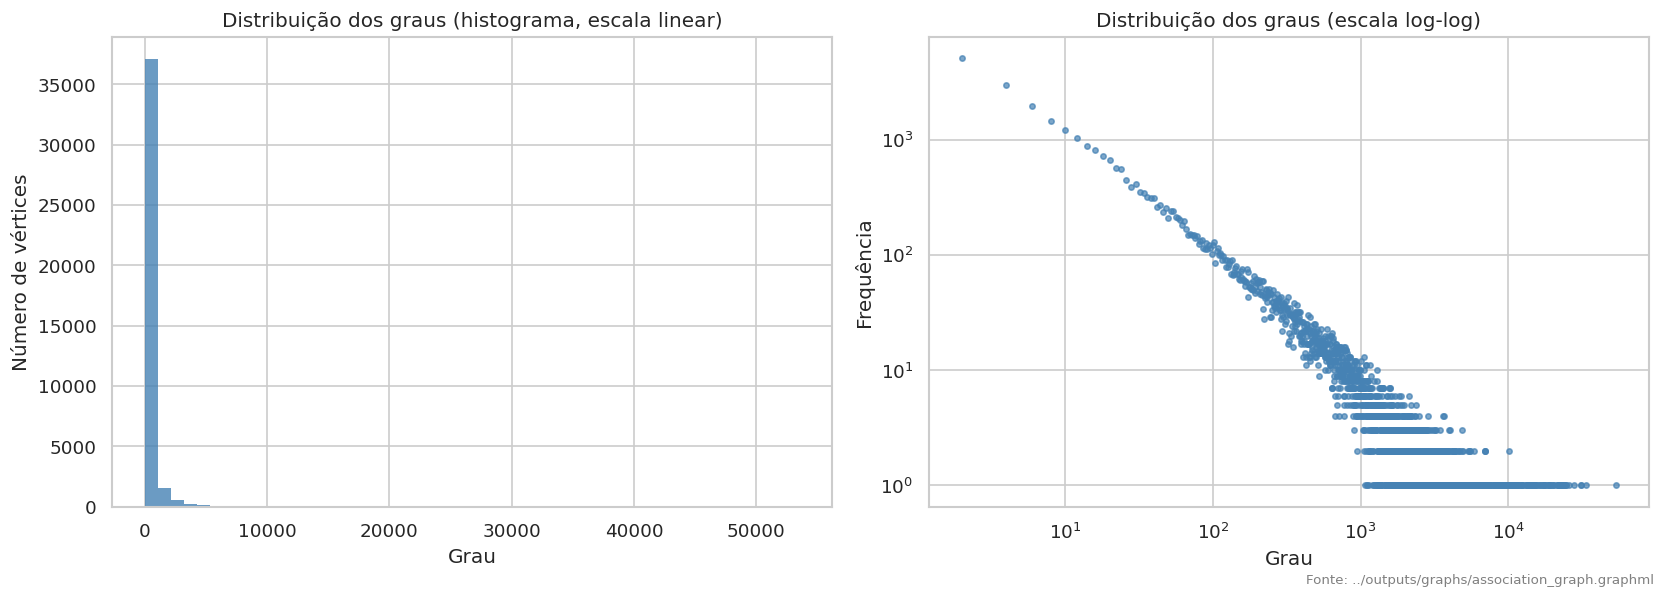

Grau mínimo:  2
Grau máximo:  53526
Grau mediano: 34.0


In [ ]:
degree_counts = Counter(degrees)
degree_values = sorted(degree_counts.keys())
degree_freqs  = [degree_counts[d] for d in degree_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma em escala linear com bins fixos — bar(..., width=0.8) ficaria
# invisível quando o range de graus cobre milhares de valores distintos
axes[0].hist(degrees, bins=50, color="steelblue", alpha=0.8, edgecolor="none")
axes[0].set_title("Distribuição dos graus (histograma, escala linear)")
axes[0].set_xlabel("Grau")
axes[0].set_ylabel("Número de vértices")

# Escala log-log — revela power-law se existir
axes[1].scatter(degree_values, degree_freqs, s=10, color="steelblue", alpha=0.7)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Distribuição dos graus (escala log-log)")
axes[1].set_xlabel("Grau")
axes[1].set_ylabel("Frequência")

fig.text(0.99, 0.01, f"Fonte: {GRAPH_PATH}", ha="right", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

print(f"Grau mínimo:  {min(degrees)}")
print(f"Grau máximo:  {max(degrees)}")
print(f"Grau mediano: {np.median(degrees):.1f}")

# 4. Componentes conexas

In [ ]:
if G.is_directed():
    components = list(nx.strongly_connected_components(G))
    component_type = "fortemente conexas"
else:
    components = list(nx.connected_components(G))
    component_type = "conexas"

n_components = len(components)
component_sizes = sorted([len(c) for c in components], reverse=True)

print(f"Número de componentes {component_type}: {n_components:,}")
print(f"Maior componente:  {component_sizes[0]:,} vértices ({100 * component_sizes[0] / n_nodes:.1f}% do total)")
if n_components > 1:
    print(f"Menor componente:  {component_sizes[-1]:,} vértice(s)")
    print(f"Tamanho mediano:   {np.median(component_sizes):.0f} vértice(s)")

Número de componentes fortemente conexas: 285
Maior componente:  36,345 vértices (91.3% do total)
Menor componente:  2 vértice(s)
Tamanho mediano:   2 vértice(s)


# 5. Distribuição dos tamanhos das componentes

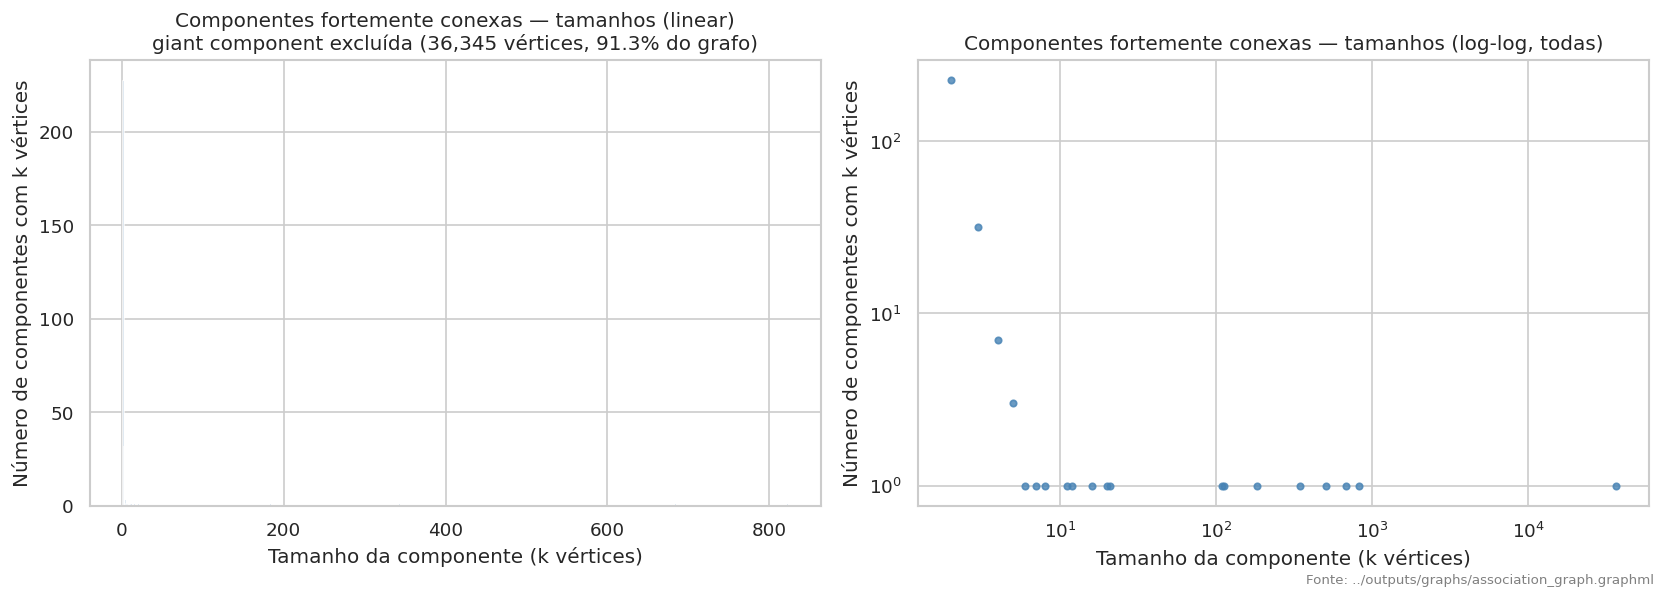


Top 10 maiores componentes:
   1. 36,345 vértices
   2. 822 vértices
   3. 684 vértices
   4. 503 vértices
   5. 343 vértices
   6. 184 vértices
   7. 113 vértices
   8. 109 vértices
   9. 21 vértices
  10. 20 vértices


In [ ]:
if n_components == 1:
    print("O grafo possui apenas uma componente — nenhuma distribuição a exibir.")
else:
    size_counts = Counter(component_sizes)
    sizes  = sorted(size_counts.keys())
    counts = [size_counts[s] for s in sizes]

    giant = component_sizes[0]
    small_sizes = [s for s in component_sizes if s != giant]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot linear: mostra apenas as componentes menores (excluindo a giant).
    # A giant dominaria completamente o eixo x, tornando o restante invisível.
    if small_sizes:
        small_counts = Counter(small_sizes)
        xs = sorted(small_counts.keys())
        ys = [small_counts[x] for x in xs]
        axes[0].bar(xs, ys, color="steelblue", alpha=0.8)
        axes[0].set_title(
            f"Componentes {component_type} — tamanhos (linear)\n"
            f"giant component excluída ({giant:,} vértices, {100*giant/n_nodes:.1f}% do grafo)"
        )
    else:
        axes[0].text(0.5, 0.5, "Apenas a giant component existe", ha="center", va="center")
        axes[0].set_title(f"Componentes {component_type} — tamanhos (linear)")
    axes[0].set_xlabel("Tamanho da componente (k vértices)")
    axes[0].set_ylabel("Número de componentes com k vértices")

    # Log-log: mostra todas, incluindo a giant
    axes[1].scatter(sizes, counts, s=15, color="steelblue", alpha=0.8)
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_title(f"Componentes {component_type} — tamanhos (log-log, todas)")
    axes[1].set_xlabel("Tamanho da componente (k vértices)")
    axes[1].set_ylabel("Número de componentes com k vértices")

    fig.text(0.99, 0.01, f"Fonte: {GRAPH_PATH}", ha="right", fontsize=8, color="gray")
    plt.tight_layout()
    plt.show()

    print("\nTop 10 maiores componentes:")
    for i, s in enumerate(component_sizes[:10], 1):
        print(f"  {i:2d}. {s:,} vértices")